<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_11_ensembles.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Basics of Ensemble Learning

In this assignment, you will learn the foundations of **ensemble learning**.

We will explore **bagging, boosting, and stacking**, visualize their behavior, and clarify how ensemble methods differ from Bayesian model averaging.

---

## Learning Goals
- Understand the motivation for ensemble methods  
- Compare bagging, boosting, and stacking  
- Visualize how ensembles reduce error or improve generalization  
- Clarify the distinction between ensembles and Bayesian model averaging  


## 1. Ensemble Learning

- **Definition**: Ensemble methods combine multiple "weak" or "base" learners into a stronger model.  
- **Motivation**: A single model may be unstable or biased, but a combination can reduce error.  

Analogy: "A crowd of diverse opinions can often outperform a single expert."

### Exercise 1
Give an example (real-life or in ML) where combining multiple perspectives leads to a better decision than relying on a single one.


Your response here

## 2. Bagging

- **Key idea**: Train multiple models on different **bootstrap samples** (random samples with replacement) and average their predictions.  
- **Effect**: Reduces variance by averaging over noisy models.  
- **Example**: Random Forest (bagging applied to decision trees).


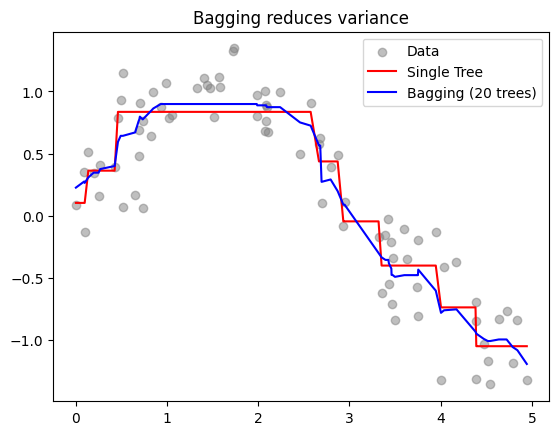

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Generate noisy data
np.random.seed(1)
X = np.sort(5 * np.random.rand(80, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.3, X.shape[0])

# Single tree
tree = DecisionTreeRegressor(max_depth=3).fit(X, y)

# Bagging: average of many trees trained on bootstraps
preds = []
for i in range(20):
    sample_idx = np.random.choice(len(X), len(X), replace=True)
    Xi, yi = X[sample_idx], y[sample_idx]
    model = DecisionTreeRegressor(max_depth=3).fit(Xi, yi)
    preds.append(model.predict(X))
bagged_pred = np.mean(preds, axis=0)

# Plot
plt.scatter(X, y, c="gray", label="Data", alpha=0.5)
plt.plot(X, tree.predict(X), label="Single Tree", color="red")
plt.plot(X, bagged_pred, label="Bagging (20 trees)", color="blue")
plt.legend()
plt.title("Bagging reduces variance")
plt.show()


### Exercise 2
Why does bagging reduce variance but not bias?  


Your response here

## 3. Boosting

- **Key idea**: Train models **sequentially**, where each new model focuses on the errors (residuals) of the previous ones.  
- **Effect**: Reduces bias by making weak learners stronger.  
- **Examples**: AdaBoost, Gradient Boosting, **XGBoost**.


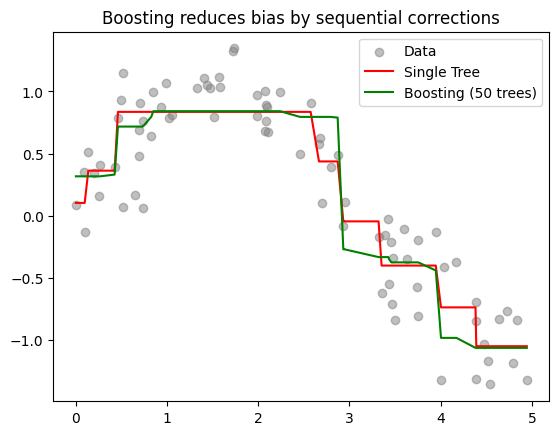

In [2]:
from sklearn.ensemble import AdaBoostRegressor

# Boosting model
boost = AdaBoostRegressor(
    DecisionTreeRegressor(max_depth=2), n_estimators=50, random_state=1
).fit(X, y)

plt.scatter(X, y, c="gray", alpha=0.5, label="Data")
plt.plot(X, tree.predict(X), label="Single Tree", color="red")
plt.plot(X, boost.predict(X), label="Boosting (50 trees)", color="green")
plt.legend()
plt.title("Boosting reduces bias by sequential corrections")
plt.show()


### Exercise 3
- How is boosting different from bagging in the way it trains its models?  
- Which type of error (bias vs variance) does boosting primarily address?  


Your response here

## 4. Stacking

- **Key idea**: Train different kinds of models, then use a **meta-model** to combine their predictions.  
- **Effect**: Learns the best way to weigh/merge multiple predictors.  


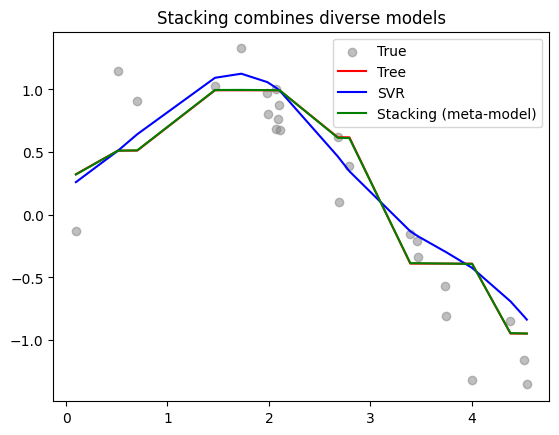

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

# Base models
model1 = DecisionTreeRegressor(max_depth=3).fit(X_train, y_train)
model2 = SVR(kernel="rbf", C=10).fit(X_train, y_train)

# Predictions from base models
pred_train = np.vstack([model1.predict(X_train), model2.predict(X_train)]).T
pred_test = np.vstack([model1.predict(X_test), model2.predict(X_test)]).T

# Meta-model
meta = LinearRegression().fit(pred_train, y_train)

plt.scatter(X_test, y_test, c="gray", label="True", alpha=0.5)

sorted_idx = np.argsort(X_test[:, 0])
X_sorted = X_test[sorted_idx]

y_tree = model1.predict(X_test)[sorted_idx]
y_svr = model2.predict(X_test)[sorted_idx]
y_stack = meta.predict(pred_test)[sorted_idx]

plt.plot(X_sorted, y_tree, color="red", label="Tree")
plt.plot(X_sorted, y_svr, color="blue", label="SVR")
plt.plot(X_sorted, y_stack, color="green", label="Stacking (meta-model)")
plt.legend()
plt.title("Stacking combines diverse models")
plt.show()


### Exercise 4
Why might stacking outperform both bagging and boosting on some datasets?  

Your response here

## 5. Important Distinction

Ensemble learning is **not** Bayesian model averaging.

- **Bayesian model averaging (BMA)**: weights models by their posterior probabilities given the data.  
- **Ensembling**: weights (or aggregates) models based on empirical performance, not Bayesian probabilities.  

**Key difference**:  
- Ensembling is a pragmatic, data-driven technique.  
- BMA is a probabilistic inference method.  


## 6. Reflection

### Exercise 6
1. Compare bagging, boosting, and stacking in terms of:
   - Training procedure  
   - Error type reduced (bias vs variance)  
   - Typical use cases  
   
2. If you had a very small dataset, which ensemble method would you avoid, and why?  


Your response here